# Nonprofit Recruiting Analysis

An analysis of a nonprofit's recruiting trends over 1126 applicants, 172 listings, and 5 platforms.

## Setup

In [103]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

### Data loading

In [ ]:
# CSV info
df = pd.read_csv("../data/raw/recruiting_data_2.csv")

In [56]:
# remove fully empty rows/columns
df = df.dropna(how="all")
df = df.dropna(axis=1, how="all")

# dropping columns
df = df.drop(columns=["Expiration", "Posted By"])

# clean column names
df.columns = df.columns.str.strip()

In [57]:
print(df.shape)
df.head()

(172, 12)


,Platform,Role,Role Group,Job Type,Applicants,Location Type,Published,Location,Location Group,Status,Views,Money Spent
0,Handshake,Nonprofit Assistant,General Staff,Job,0.0,Onsite or remote,4/15/2022,"Raleigh, North Carolina",North Carolina,Closed,NaN,NaN
1,Handshake,Volunteer Staff Member,General Staff,Internship,13.0,Onsite,6/15/2022,"Raleigh, North Carolina +1",North Carolina,Closed,NaN,NaN
2,Handshake,Accounting Manager-Volunteer/Internship,Operations/Administration,Volunteer,1.0,Onsite or remote,8/30/2022,"Raleigh, North Carolina",North Carolina,Closed,NaN,NaN
3,Handshake,Development Director- Volunteer/Internship,Fundraising,Volunteer,1.0,Onsite or remote,8/30/2022,"Raleigh, North Carolina",North Carolina,Closed,NaN,NaN
4,Handshake,Program Manager-Volunteer/Internship,Programs/Project Management,Volunteer,1.0,Onsite or remote,8/30/2022,"Raleigh, North Carolina",North Carolina,Closed,NaN,NaN


## Data cleaning

In [58]:
# drop listings that are drafts
df = df[df["Status"] != "Draft"]

df_raw = df.copy()

# View counts are only available for Idealist postings
df["Views"] = df["Views"].fillna(pd.NA)

# standardizing data types
df["Applicants"] = pd.to_numeric(df["Applicants"], errors="coerce")
df["Views"] = pd.to_numeric(df["Views"], errors="coerce")
df["Published"] = pd.to_datetime(df["Published"], errors="coerce")

# variables for year and month published
df["Year Published"] = df["Published"].dt.year.astype("Int64")
df["Month Published"] = df["Published"].dt.month.astype("Int64")
df["Year-Month Published"] = df["Published"].dt.to_period("M").astype(str)

df.to_csv("cleaned_recruiting_data.csv", index=False)

## Data quality

In [59]:
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": [df[col].dtype for col in df.columns],
    "missing": [df[col].isna().sum() for col in df.columns],
    "unique_values": [df[col].nunique(dropna=True) for col in df.columns]
})
summary

,column,dtype,missing,unique_values
0,Platform,str,0,5
1,Role,str,0,84
2,Role Group,str,6,10
3,Job Type,str,34,5
4,Applicants,float64,0,30
5,Location Type,str,0,7
6,Published,datetime64[us],35,51
7,Location,str,0,22
8,Location Group,str,6,3
9,Status,str,0,7


Missing published date information for LinkedIn listings. Trends cannot be combined across platforms since LinkedIn is missing. Views data is only available for Idealist and money spent data is only available for LinkedIn.

In [60]:
df.head(3)

,Platform,Role,Role Group,Job Type,Applicants,Location Type,Published,Location,Location Group,Status,Views,Money Spent,Year Published,Month Published,Year-Month Published
0,Handshake,Nonprofit Assistant,General Staff,Job,0.0,Onsite or remote,2022-04-15,"Raleigh, North Carolina",North Carolina,Closed,NaN,NaN,2022,4,2022-04
1,Handshake,Volunteer Staff Member,General Staff,Internship,13.0,Onsite,2022-06-15,"Raleigh, North Carolina +1",North Carolina,Closed,NaN,NaN,2022,6,2022-06
2,Handshake,Accounting Manager-Volunteer/Internship,Operations/Administration,Volunteer,1.0,Onsite or remote,2022-08-30,"Raleigh, North Carolina",North Carolina,Closed,NaN,NaN,2022,8,2022-08


In [61]:
# checks to identify records that may need manual review
quality_flags = {}

if "Applicants" in df.columns:
    quality_flags["negative_applicants"] = int((df["Applicants"] < 0).sum())

if "Views" in df.columns:
    quality_flags["negative_views"] = int((df["Views"] < 0).sum())
    quality_flags["views_missing"] = int(df["Views"].isna().sum())
    quality_flags["views_zero_or_missing"] = int((df["Views"].fillna(0) <= 0).sum())

if {"Published", "Expiration"}.issubset(df.columns):
    quality_flags["missing_published_date"] = int(df["Published"].isna().sum())
    quality_flags["missing_expiration_date"] = int(df["Expiration"].isna().sum())

quality_flags_df = pd.DataFrame(list(quality_flags.items()), columns=["quality_check", "count"])
display(quality_flags_df)

,quality_check,count
0,negative_applicants,0
1,negative_views,0
2,views_missing,127
3,views_zero_or_missing,128


## Exploratory data analysis

In [62]:
df.shape

(170, 15)

Mean applicants: 6.623529411764705
Median applicants: 2.0
Skewness: 3.529512562456348


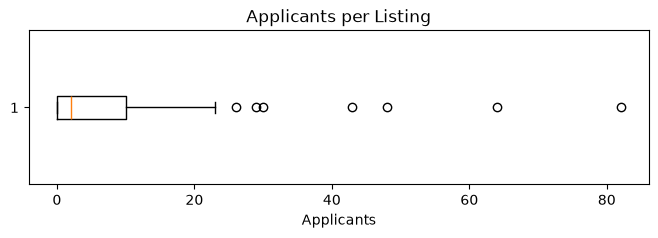

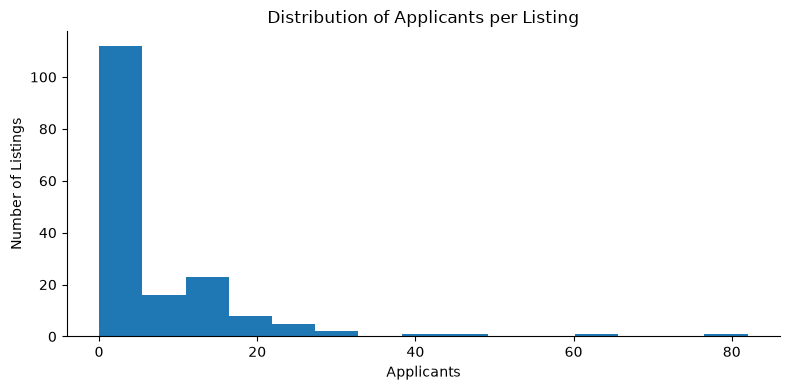

In [96]:
# distribution of dataset

# metrics
print("Mean applicants:", df["Applicants"].mean())
print("Median applicants:", df["Applicants"].median())
print("Skewness:", df["Applicants"].skew())

# boxplot
plt.figure(figsize=(8,2))
plt.boxplot(df["Applicants"].dropna(), orientation='horizontal')
plt.title("Applicants per Listing")
plt.xlabel("Applicants")
plt.show()

# histogram
fig, ax = plt.subplots(figsize=(8, 4))
plt.hist(df["Applicants"], bins=15)
plt.title("Distribution of Applicants per Listing")
plt.xlabel("Applicants")
plt.ylabel("Number of Listings")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


The distribution reveals data is heavily skewed. The median should be used rather than mean for calculating average applicants.

In [64]:
recruiting_summary = df.agg(
    listings_count=("Applicants", "count"),
    total_applicants=("Applicants", "sum"),
    average_applicants=("Applicants", "mean"),
    median_applicants=("Applicants", "median"),
    zero_applicant_count=("Applicants", lambda x: (x == 0).sum()),
    zero_applicant_rate=("Applicants", lambda x: (x == 0).mean())
)

recruiting_summary

,Applicants
listings_count,170.000000
total_applicants,1126.000000
average_applicants,6.623529
median_applicants,2.000000
zero_applicant_count,56.000000
zero_applicant_rate,0.329412


About one-third of listings recieved 0 applicants. The top seven listings account for a disproportionate share of the 1,126 total.

In [65]:
platform_summary = df.groupby("Platform").agg(
    listings_count=("Applicants", "count"),
    total_applicants=("Applicants", "sum"),
    average_applicants=("Applicants", "mean"),
    median_applicants=("Applicants", "median"),
    zero_applicant_count=("Applicants", lambda x: (x == 0).sum()),
    zero_applicant_rate=("Applicants", lambda x: (x == 0).mean())
)

platform_summary

,listings_count,total_applicants,average_applicants,median_applicants,zero_applicant_count,zero_applicant_rate
Platform,,,,,,
Handshake,49,235.0,4.795918,1.0,18,0.367347
Idealist,43,317.0,7.372093,2.0,15,0.348837
Indeed,35,126.0,3.600000,1.0,17,0.485714
LinkedIn,34,403.0,11.852941,10.0,5,0.147059
Symplicity,9,45.0,5.000000,4.0,1,0.111111


Overview of each platform. LinkedIn has the most consistent applicant counts. 

## Applicants by platform

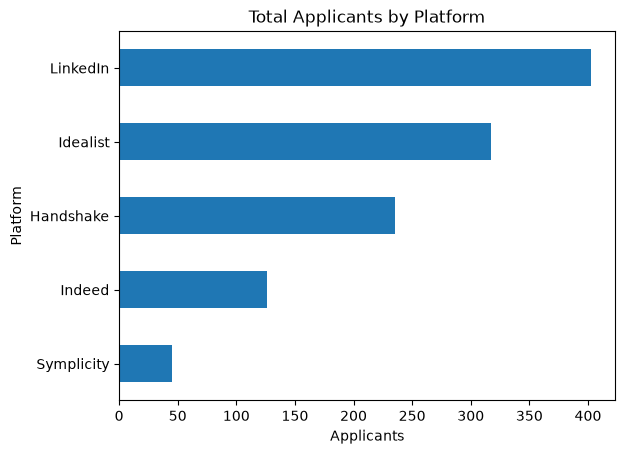

In [68]:
applicants_by_platform = df.groupby("Platform")["Applicants"].sum().sort_values(ascending=True)
applicants_by_platform.plot(kind="barh")
plt.title("Total Applicants by Platform")
plt.xlabel("Applicants")
plt.show()


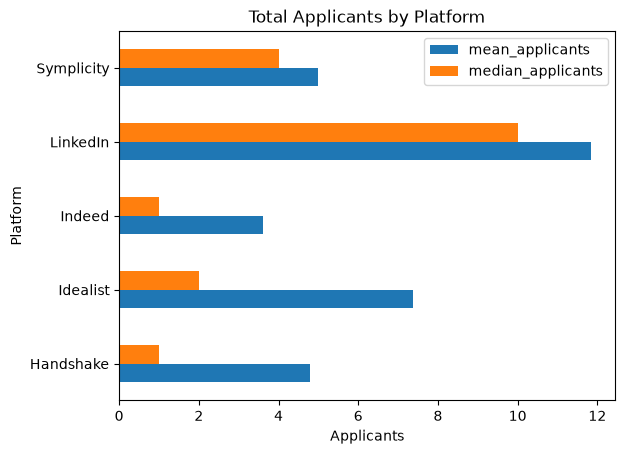

In [79]:
average_applicants_by_platform = df.groupby("Platform")["Applicants"].agg(mean_applicants="mean", median_applicants="median")
average_applicants_by_platform.plot(kind="barh")
plt.title("Total Applicants by Platform")
plt.xlabel("Applicants")
plt.show()


LinkedIn has the highest total applicants and highest applicant rates by platform.

## Time analysis

Analysis of how applicant trends have changed overtime. Are we making progress? Have our applicant rates increased over time?

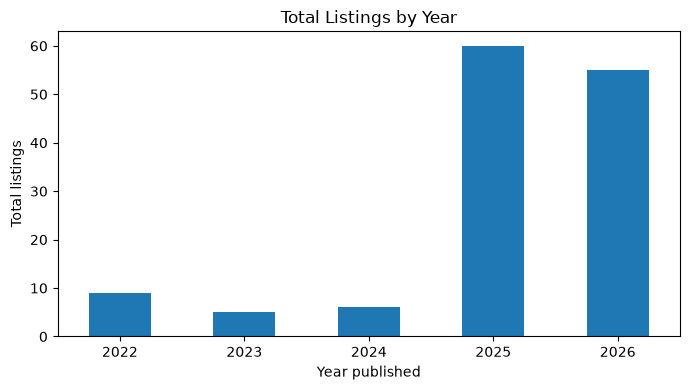

Year Published
2022     9
2023     5
2024     6
2025    60
2026    55
Name: Applicants, dtype: int64

In [93]:
# group applicants by year 
listings_by_year = df.groupby("Year Published")["Applicants"].agg("count")

# plot applicants by year
listings_by_year.plot(kind="bar", figsize=(7, 4), title="Total Listings by Year")
plt.xlabel("Year published")
plt.ylabel("Total listings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

listings_by_year


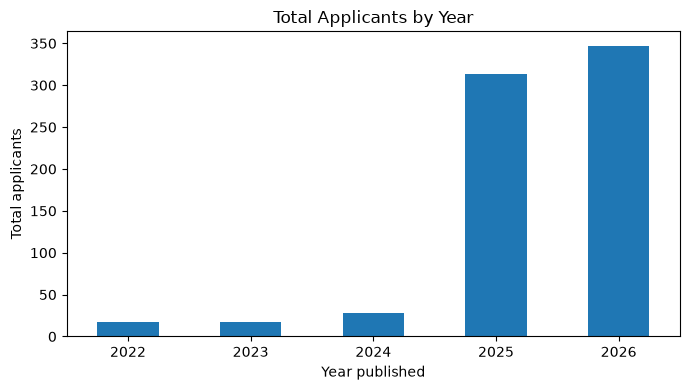

Year Published
2022     17.0
2023     17.0
2024     28.0
2025    314.0
2026    347.0
Name: Applicants, dtype: float64

In [90]:
# group applicants by year 
applicants_by_year = df.groupby("Year Published")["Applicants"].agg("sum")

# plot applicants by year
applicants_by_year.plot(kind="bar", figsize=(7, 4), title="Total Applicants by Year")
plt.xlabel("Year published")
plt.ylabel("Total applicants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

applicants_by_year


Total applicant numbers have been increasing per year.

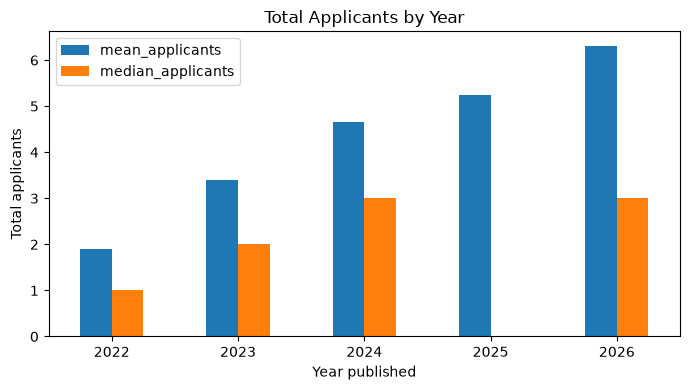

,mean_applicants,median_applicants
Year Published,,
2022,1.888889,1.0
2023,3.400000,2.0
2024,4.666667,3.0
2025,5.233333,0.0
2026,6.309091,3.0


In [87]:
# group applicants by year 
applicants_by_year = df.groupby("Year Published")["Applicants"].agg(mean_applicants="mean", median_applicants="median")

# plot applicants by year
applicants_by_year.plot(kind="bar", figsize=(7, 4), title="Total Applicants by Year")
plt.xlabel("Year published")
plt.ylabel("Total applicants")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

applicants_by_year


Median applicant rates have only slightly increased, with a major drop in 2025 rate being 0.

## Location analysis

Analysis of whether location affects applicant rates. 

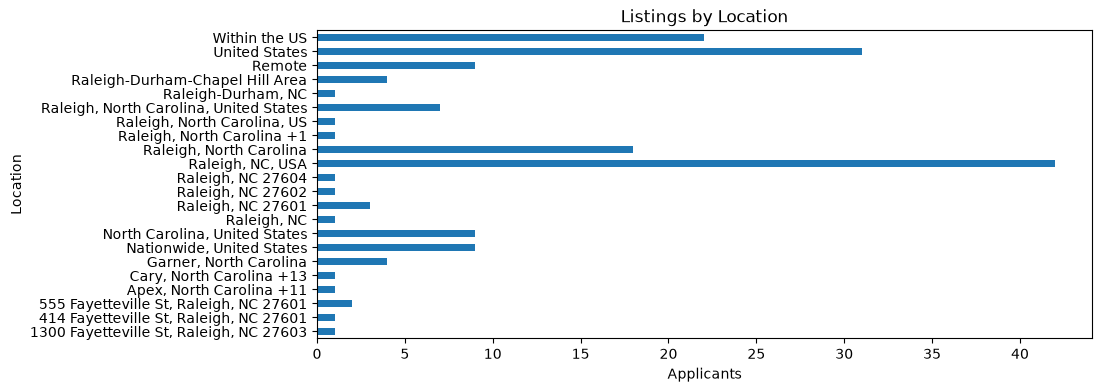

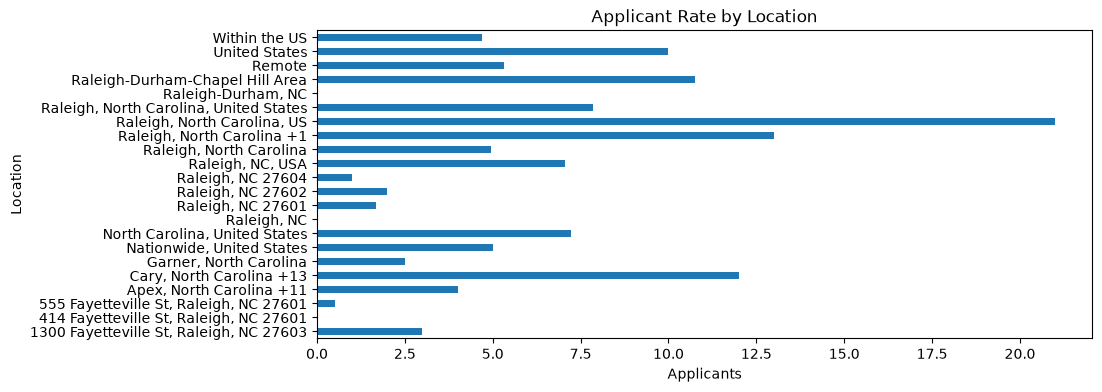

In [94]:
total_applicants = df.groupby("Location")["Applicants"].sum()
total_listings = df.groupby("Location").size()

total_listings.plot(kind="barh", figsize=(10, 4), title="Listings by Location")
plt.xlabel("Applicants")
plt.show()

applicant_rate_by_location = total_applicants / total_listings
applicant_rate_by_location.plot(kind="barh", figsize=(10, 4))
plt.title("Applicant Rate by Location")
plt.xlabel("Applicants")
plt.show()

## Role analysis

Analysis of applicants by role type. Do we recieve more applicants for certain roles such as managers or CEOs?

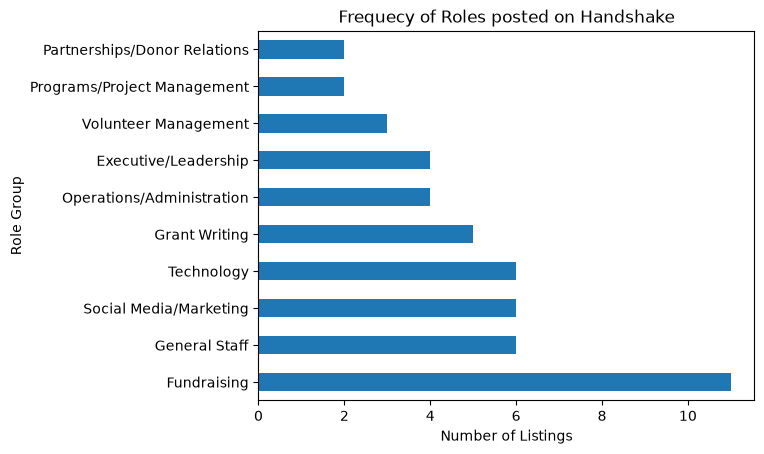

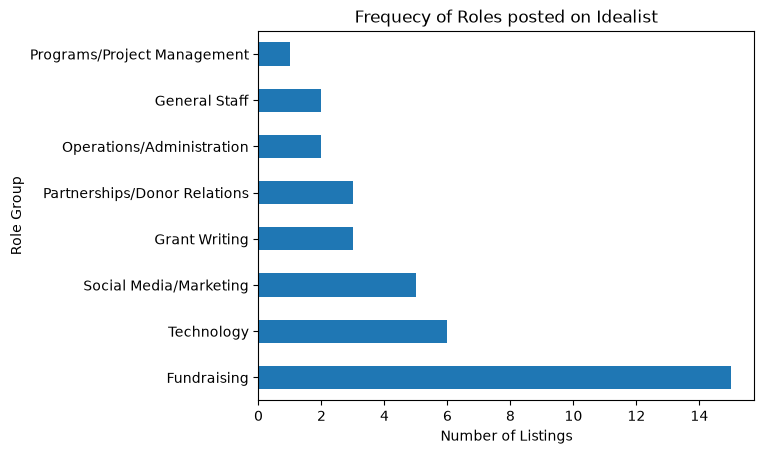

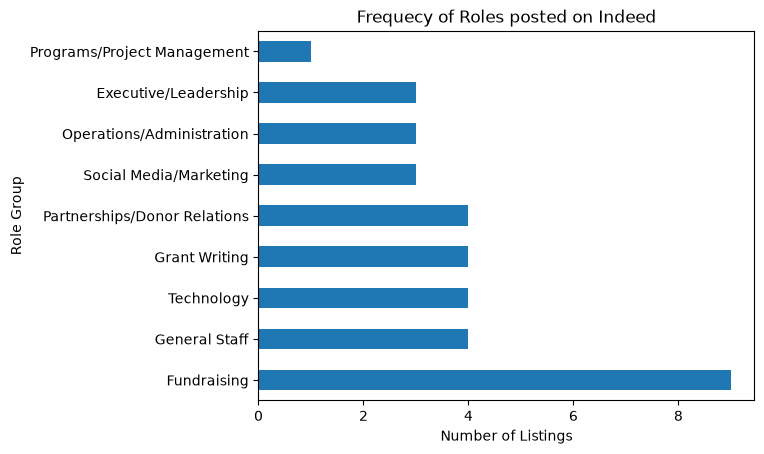

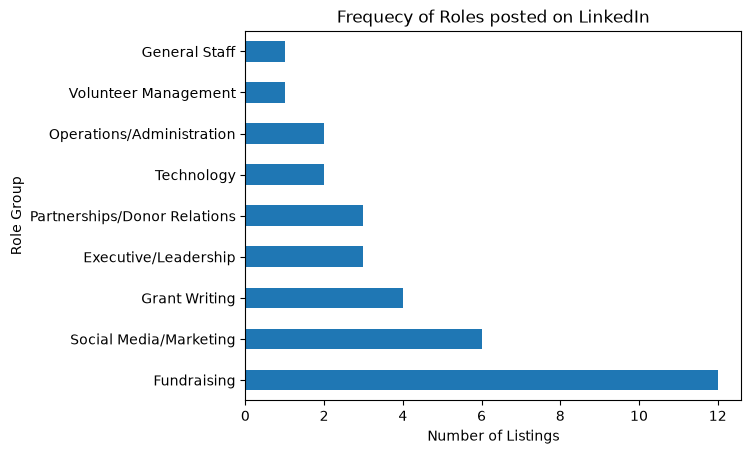

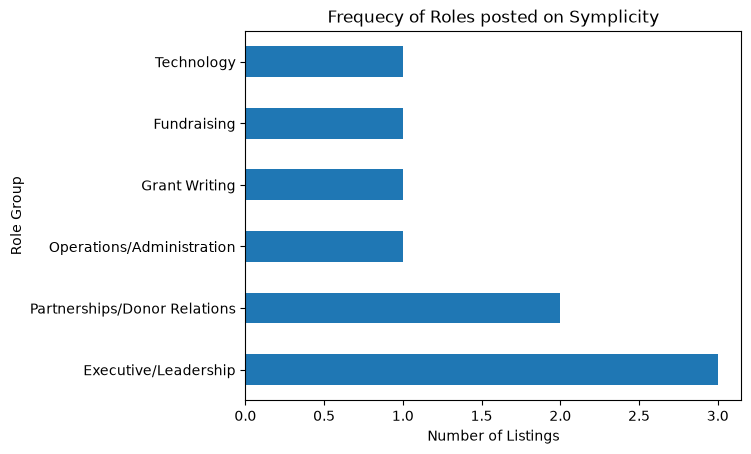

In [95]:
df[df["Platform"] == "Handshake"]["Role Group"].value_counts().plot(kind="barh")
plt.title("Frequecy of Roles posted on Handshake")
plt.xlabel("Number of Listings")
plt.show()

df[df["Platform"] == "Idealist"]["Role Group"].value_counts().plot(kind="barh")
plt.title("Frequecy of Roles posted on Idealist")
plt.xlabel("Number of Listings")
plt.show()

df[df["Platform"] == "Indeed"]["Role Group"].value_counts().plot(kind="barh")
plt.title("Frequecy of Roles posted on Indeed")
plt.xlabel("Number of Listings")
plt.show()

df[df["Platform"] == "LinkedIn"]["Role Group"].value_counts().plot(kind="barh")
plt.title("Frequecy of Roles posted on LinkedIn")
plt.xlabel("Number of Listings")
plt.show()

df[df["Platform"] == "Symplicity"]["Role Group"].value_counts().plot(kind="barh")
plt.title("Frequecy of Roles posted on Symplicity")
plt.xlabel("Number of Listings")
plt.show()

Fundraising roles are the most heavily posted across 4/5 of the platforms.

## Role framing analysis

Analysis on whether framing (volunteer vs internship) affects applicants rates.

## Miscellaneous analysis

### Money vs applicants analysis

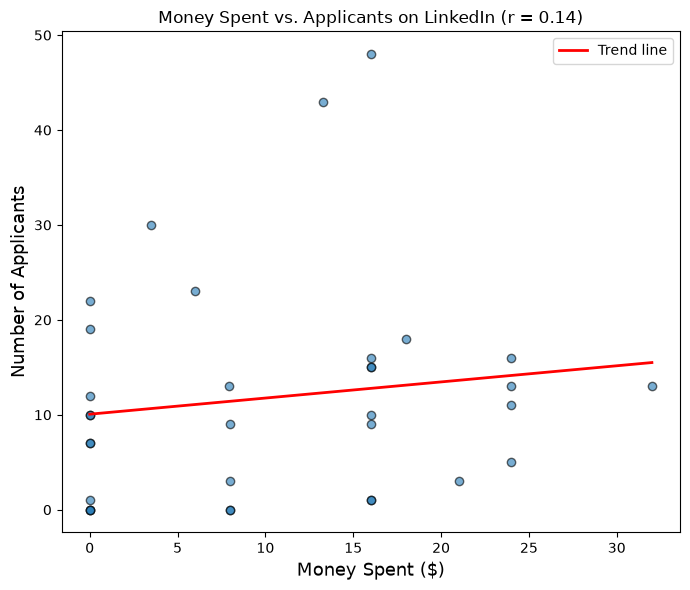

In [107]:
linkedin_df = df[(df["Platform"] == "LinkedIn") & df["Money Spent"].notna()].copy()

# Pearson correlation coefficient between Money Spent and Applicants
corr = linkedin_df["Money Spent"].corr(linkedin_df["Applicants"])

# Scatter plot of the two variables
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(linkedin_df["Money Spent"], linkedin_df["Applicants"], alpha=0.6, edgecolor="k")

# Add a linear trend line
m, b = np.polyfit(linkedin_df["Money Spent"], linkedin_df["Applicants"], 1)
x_line = np.linspace(linkedin_df["Money Spent"].min(), linkedin_df["Money Spent"].max(), 100)
ax.plot(x_line, m * x_line + b, color="red", linewidth=2, label="Trend line")

ax.set_title(f"Money Spent vs. Applicants on LinkedIn (r = {corr:.2f})")
ax.set_xlabel("Money Spent ($)", fontsize=13)
ax.set_ylabel("Number of Applicants", fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

No correlation between the amount of money spent on a listing and the number of applicants it recieves. 

### Views vs applicants analysis

In [110]:
# idealist_df = df[(df["Platform"] == "Idealist") & df["Money Spent"].notna()].copy()

# # Pearson correlation coefficient between Money Spent and Applicants
# corr = idealist_df["Money Spent"].corr(idealist_df["Applicants"])

# # Scatter plot of the two variables
# fig, ax = plt.subplots(figsize=(7, 6))
# ax.scatter(idealist_df["Views"], idealist_df["Applicants"], alpha=0.6, edgecolor="k")

# # Add a linear trend line
# m, b = np.polyfit(idealist_df["Views"], idealist_df["Applicants"], 1)
# x_line = np.linspace(idealist_df["Views"].min(), idealist_df["Views"].max(), 100)
# ax.plot(x_line, m * x_line + b, color="red", linewidth=2, label="Trend line")

# ax.set_title(f"Money Spent vs. Applicants on Idealist (r = {corr:.2f})")
# ax.set_xlabel("Money Spent ($)", fontsize=13)
# ax.set_ylabel("Number of Applicants", fontsize=13)
# ax.legend()
# plt.tight_layout()
# plt.show()

# Key Findings